In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print("Project environment ready!")

Project environment ready!


In [2]:
import os
dataset_path =r"C:\Users\moriy\OneDrive\Desktop\Plant Disease Detection\PlantVillageDataset\PlantVillage"
folders=os.listdir(dataset_path)
print("Number of classes:",len(folders))
print("Some classes:", folders[:5])

Number of classes: 16
Some classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy']


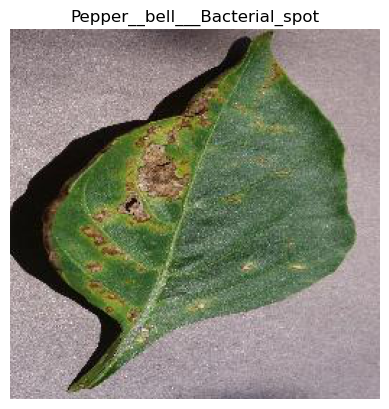

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
dataset_path=r"C:\Users\moriy\OneDrive\Desktop\Plant Disease Detection\PlantVillageDataset\PlantVillage"
folders=os.listdir(dataset_path)
class_name=folders[0]
class_path=os.path.join(dataset_path,class_name)
image_name=os.listdir(class_path)[0]
image_path=os.path.join(class_path,image_name)
img=Image.open(image_path)
plt.imshow(img)
plt.title(class_name)
plt.axis("off")
plt.show()

In [4]:
import tensorflow as tf
img_size=(224,224)
batch_size=32
dataset=tf.keras.preprocessing.image_dataset_from_directory(dataset_path,image_size=img_size,batch_size=batch_size)
print("Dataset loaded successfully!") 

Found 41276 files belonging to 16 classes.
Dataset loaded successfully!


In [5]:
for images,labels in dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [6]:
from tensorflow.keras import layers,models

In [7]:
#cnn model
model=models.Sequential([layers.Rescaling(1./255,input_shape=(224,224,3)),
                        layers.Conv2D(32,(3,3),activation='relu'),
                        layers.MaxPooling2D(),
                        layers.Conv2D(64,(3,3),activation='relu'),
                        layers.MaxPooling2D(),
                        layers.Conv2D(128,(3,3),activation='relu'),
                        layers.MaxPooling2D(),
                        layers.Flatten(),
                        layers.Dense(128,activation='relu'),
                        layers.Dense(16,activation='softmax')
                       ])


C:\Users\moriy\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,024 (42.61 MB)

 Trainable params: 11,171,024 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

In [10]:
history=model.fit(train_dataset,validation_data=validation_dataset,epochs=5)

NameError: name 'train_dataset' is not defined

In [ ]:
import tensorflow as tf
import os

In [11]:
dataset_path=r"C:\Users\moriy\OneDrive\Desktop\Plant Disease Detection\PlantVillageDataset\train_val_test\train"

In [12]:
os.listdir(dataset_path)

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_healthy',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Tomato_YellowLeaf__Curl_Virus']

In [13]:
#training dataset
img_size=(224,224)
batch_size=32
train_dataset=tf.keras.utils.image_dataset_from_directory(dataset_path,
                                                         validation_split=0.2,
                                                         subset="training",
                                                         seed=123,
                                                         image_size=img_size,
                                                         batch_size=batch_size
                                                        )

Found 14437 files belonging to 15 classes.
Using 11550 files for training.


In [14]:
#validation dataset
validation_dataset=tf.keras.utils.image_dataset_from_directory(dataset_path,
                                                               validation_split=0.2,
                                                               subset="validation",
                                                               seed=123,
                                                               image_size=img_size,
                                                               batch_size=batch_size
                                                              )

Found 14437 files belonging to 15 classes.
Using 2887 files for validation.


In [15]:
#check classes
class_names=train_dataset.class_names
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [16]:
#train the model
history=model.fit(train_dataset,
                  validation_data=validation_dataset,
                  epochs=5
                 )

Epoch 1/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 344s 948ms/step - accuracy: 0.6309 - loss: 1.1713 - val_accuracy: 0.7877 - val_loss: 0.6442
Epoch 2/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 342s 947ms/step - accuracy: 0.8352 - loss: 0.4931 - val_accuracy: 0.8642 - val_loss: 0.4024
Epoch 3/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 348s 963ms/step - accuracy: 0.9053 - loss: 0.2805 - val_accuracy: 0.8490 - val_loss: 0.4516
Epoch 4/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 355s 985ms/step - accuracy: 0.9394 - loss: 0.1821 - val_accuracy: 0.8691 - val_loss: 0.4530
Epoch 5/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9533 - loss: 0.1376 - val_accuracy: 0.8705 - val_loss: 0.4315


In [18]:
model.save("plant_disease_model.h5")

In [19]:
from tensorflow.keras.models import load_model
model=load_model("plant_disease_model.h5")

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
img_path=r"C:\Users\moriy\OneDrive\Desktop\Plant Disease Detection\test.JPG"
img=image.load_img(img_path,target_size=(224,224))
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array=img_array/255.0
#prediction
prediction=model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 3.5783384e-38 1.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00]]


In [21]:
#convert to class name
class_names=train_dataset.class_names
predicted_class=class_names[np.argmax(prediction)]
print("Predicted:",predicted_class)

Predicted: Tomato_Late_blight


In [23]:
import os
print(os.path.exists(img_path))

True


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


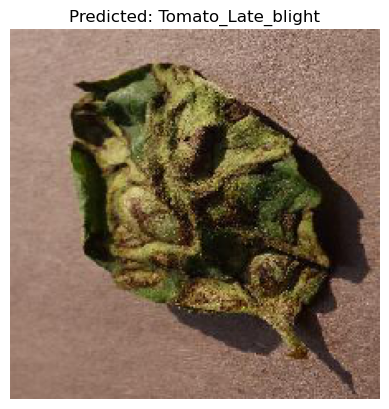

In [24]:
import matplotlib.pyplot as plt

# Load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediction
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

# SHOW IMAGE + OUTPUT
plt.imshow(img)
plt.title("Predicted: " + predicted_class)
plt.axis("off")
plt.show()